In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata, min_counts=1, min_p=0.6)

/tmp/ipykernel_368884/1587735839.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'wt':0,'heterozygous':1,'mutated':2})


5398


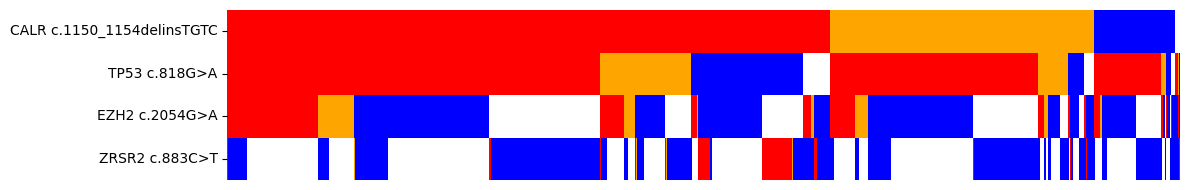

In [3]:
target1 = 'CALR c.1150_1154delinsTGTC'
target2 = 'TP53 c.818G>A'
target3 = 'EZH2 c.2054G>A'
target4 = 'ZRSR2 c.883C>T'

df = adata.obsm['genotype_call'][[target1,target2,target3,target4]]

# df = df.loc[df[target1].notna()].reset_index(drop=True)
df = df.loc[(df.notna().sum(axis=1) >=3)].reset_index(drop=True)

df = df.replace({'wt':0,'heterozygous':1,'mutated':2})
df = df.sort_values([target1,target2,target3,target4],ascending=False)
df.reset_index(inplace=True, drop=True)

fig,ax = plt.subplots(figsize=(12,2))
cmap = matplotlib.colors.ListedColormap(['blue','orange', 'red'])
sns.heatmap(df.transpose(), cmap=cmap, cbar=False, ax=ax, alpha=1)
plt.gca().set_xticks([])
plt.xlabel('')
plt.tight_layout()

print(len(df))

plt.savefig('../plots/variant_heatmap.pdf')